# Домашнее задание 1. Постановка и классификация задач, МНК, LP

**Выдано:** 9 сентября 2026. **Срок сдачи:** 23 сентября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках) и пришлите `.ipynb` **с выполненными ячейками** и его PDF-экспорт (`File → Save and Export Notebook As → PDF` или `HTML → печать в PDF`). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 1 ([конспект](../lectures/lecture01/lecture01.md), [демо](../lectures/lecture01/demo01.ipynb)). Ничего сверх лекции не требуется.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog, minimize

rng = np.random.default_rng(2026)   # не меняйте seed: данные должны совпадать у всех

## Задача 1. Классификация (4 балла)

Для каждой задачи (а)–(г) запишите её в стандартной форме

$$\min_x f(x) \quad\text{при}\quad g(x) = 0,\; h(x) \ge 0,$$

явно указав, что такое $x$ (и его размерность), $f$, $g$, $h$. Затем определите класс: LP / QP / QCQP / NLP; с ограничениями или без; выпуклая или нет (обоснуйте там, где это очевидно). По 1 баллу за пункт.

**(а)** Найти точку прямой $\{x \in \mathbb{R}^3 : x_1 + x_2 + x_3 = 1,\; x_1 - x_3 = 0\}$, ближайшую к точке $(1, 2, 3)$. *Дополнительно:* найдите эту точку (руками или численно).

**(б)** Диета: $n$ продуктов с ценами $c_j$; $m$ питательных веществ, продукт $j$ содержит $A_{ij}$ единиц вещества $i$. Купить продукты минимальной стоимости так, чтобы каждого вещества было не меньше $b_i$.

**(в)** Найти вписанный в единичный круг прямоугольник наибольшей площади (стороны параллельны осям).

**(г)** Подогнать модель $\varphi(t; x) = x_1 \sin(x_2 t + x_3)$ к измерениям $(t_i, y_i)$, $i = 1, \dots, N$, по критерию суммы квадратов невязок.

**(д, бонус +1)** $\min_{x \in \mathbb{R}^n} \max_i |a_i^\top x - b_i|$ (подгонка в чебышёвской норме). Переформулируйте как гладкую задачу с одной дополнительной переменной, по образцу переформулировки из раздела 8 лекции. Какой это класс?

**(а)**

**Ответ:** _(ваш текст; формулы — в $\LaTeX$)_

| | |
|---|---|
| переменные | $x = (x_1, x_2, x_3)$ — координаты искомой точки на прямой |
| $f(x)$ | $\tfrac12∥x−p∥^2$ = $\tfrac12[(x_1 - 1)^2 + (x_2 - 2)^2 + (x_3 - 3)^2]$, $p = (1, 2, 3)$ |
| $g, h$ | $ g_1(x) = x_1 + x_2 + x_3 - 1 = 0$,  $g_2(x) = x_1 - x_3 = 0$|
| класс | QP, выпуклая с ограничениями типа равенств,  $Q \succ 0$ ($f(x) = \tfrac12 x^\top Q x + c^\top x$ собственные числа положительны)|
| в SciPy | `minimize(f, x0, method="SLSQP", jac=... constraints=[...])` |

In [17]:
# ваш код
p = np.array([1, 2, 3])
def f_a(x):
    return 0.5 * np.sum((x - p)**2)

def grad_a(x):
    return x - p

g1_a = {'type': 'eq', 'fun': lambda x: x[0] + x[1] + x[2] - 1}
g2_a = {'type': 'eq', 'fun': lambda x: x[0] - x[2]}

x_0 = (0, 0, 0)

res_a = minimize(f_a, x_0, method='SLSQP', jac=grad_a, constraints=[g1_a, g2_a])

print(res_a)

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 5.166666666666667
           x: [ 3.333e-01  3.333e-01  3.333e-01]
         nit: 2
         jac: [-6.667e-01 -1.667e+00 -2.667e+00]
        nfev: 2
        njev: 2
 multipliers: [-1.667e+00  1.000e+00]


**(б)**

**Ответ:** _(ваш текст; формулы — в $\LaTeX$)_

| | |
|---|---|
| переменные | $x = (x_1, x_2, ..., x_n)$ – количество единиц каждого продукта |
| $f(x)$ | $f(x) = \sum_{j=1}^{n} c_j x_j = c^\top x$  |
| $g$ | нет |
| $h(x) \ge 0$ | $\sum A_{ij}x_i \ge b_i$, т.е $Ax - b \ge 0$ , $-Ax \le -b$ |
| класс | LP, линейная, ограничения линейные |
| в SciPy | `linprog(c, A_ub=-A, b_ub=-b, bounds=[0, None]*n)`, n – количество товара |

**(в)**

**Ответ:** _(ваш текст; формулы — в $\LaTeX$)_


| | |
|---|---|
| переменные | $x = (x_1, x_2)$ — координаты точки прямоугольника, лежащей в первой четверти, если начало координат – центр окружности |
| $f(x)$ | $ S = - 4x_1x_2$ – минус тк минимизируем отрицательную площадь, 4 тк $х_1, х_2$ – половины сторон прямоугольника|
| $g, h$ | $ g(x) = \sqrt{x_1^2+х_2^2} - 1 = 0$|
| класс | NLP, невыпуклая, ограничения нелинейные,  $ \lambda=\pm4$, не $\succ0$|
| в SciPy | `minimize(f, x0, method="SLSQP", constraints=[...], bounds=)` |

**(г)**

**Ответ:** _(ваш текст; формулы — в $\LaTeX$)_

| | |
|---|---|
| переменные | $x = (x_1, x_2, x_3)$  |
| $f(x)$ | $\tfrac12 \sum_i (\varphi(t_i; x) - y_i)^2 = \tfrac12 \Vert r(x)\Vert^2$ |
| $g, h$ | нет |
| класс | NLP, невыпуклая – нелинейна по $x_2, x_3$, |
| в SciPy | `minimize(f, x0, method="BFGS")`  |

**(д, бонус)**

**Ответ:** _(ваш текст; формулы — в $\LaTeX$)_

$\min_{x \in \mathbb{R}^n} \max_i |a_i^\top x - b_i|$

Введем $s \ge \max_i|a_i^\top x - b_i|$, тогда задача сводится к:

$\min_{x \in \mathbb{R}^n}s$  при $-s \le \max_i |a_i^\top x - b_i| \le s$

--> $\min_{x\in\mathbb{R}^n,\ s\in\mathbb{R}}\ s \quad \text{при} \quad -s\le a_i^\top x-b_i\le s,\ \ i=1,\dots,m$

Класс функции: линейная с ограничениями типа неравенств

## Задача 2. Практика (6 баллов)

**(а) Линейный МНК и переобучение (3 балла).** Ниже сгенерированы обучающая и тестовая выборки: $y = \sin(2\pi t) + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, 0.1^2)$. Для каждой степени $d = 1, \dots, 15$ подгоните полином $\varphi(t; x) = x_0 + x_1 t + \dots + x_d t^d$ методом наименьших квадратов (`numpy.linalg.lstsq`; матрицу $A$ удобно строить через `np.vander(t, d + 1, increasing=True)`). Постройте график зависимости среднеквадратичной ошибки на обучающей и на тестовой выборках от $d$ (ось $y$ — логарифмическая). Объясните поведение обеих кривых в двух-трёх предложениях: почему одна монотонна, а другая нет?

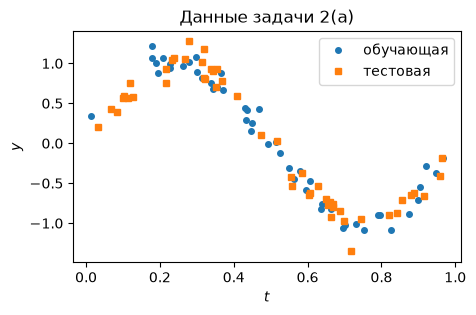

In [18]:
N = 50
t_train = np.sort(rng.uniform(0, 1, N))
y_train = np.sin(2 * np.pi * t_train) + 0.1 * rng.standard_normal(N)
t_test = np.sort(rng.uniform(0, 1, N))
y_test = np.sin(2 * np.pi * t_test) + 0.1 * rng.standard_normal(N)

plt.figure(figsize=(5, 3))
plt.plot(t_train, y_train, "o", ms=4, label="обучающая")
plt.plot(t_test, y_test, "s", ms=4, label="тестовая")
plt.legend(); plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 2(а)")
plt.show()

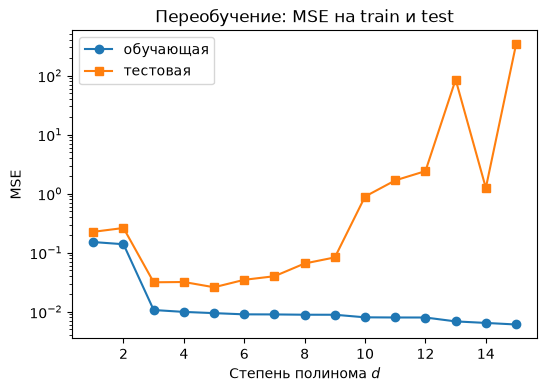

In [22]:
# ваш код
def design(t, deg):
    return np.vander(t, deg + 1, increasing=True)
mse_train_list = []
mse_test_list = []

for i in range(1, 16):

    A_train = design(t_train, i)
    x_lstsq, *_ = np.linalg.lstsq(A_train, y_train, rcond=None)
    pred_train = A_train@x_lstsq
    mse_train = np.mean((pred_train - y_train)**2)
    mse_train_list.append(mse_train)

    A_test = design(t_test, i)
    pred_test = A_test @ x_lstsq
    mse_test = np.mean((pred_test - y_test)**2)
    mse_test_list.append(mse_test)

plt.figure(figsize=(6, 4))
plt.plot(range(1, 16), mse_train_list, "o-", label="обучающая")
plt.plot(range(1, 16), mse_test_list, "s-", label="тестовая")
plt.yscale("log")
plt.xlabel("Cтепень полинома $d$")
plt.ylabel("MSE")
plt.legend()
plt.title("Переобучение: MSE на train и test")
plt.show()

**Ответ:** 

Ну вот мы увидели переобучение, на обучающей выборке ошибка монотонно убывает с увеличеснием степени полинома, а на тестовой ведет себя аналогично лишь при малых степенях. При обучении полинома с большой степенью свободы, он становится слишком гибким, что дает ему возможность подстраиваться под шумы конкретной выборки трейна, чем больше степень полинома, тем больше он подстраиватся под конкретные точки. Именно поэтому на тесте ошибка быстро растет, полином уловил не общую кривую, а более точное расположение точек первой выборки.

**(б) LP: диета (3 балла).** Решите задачу диеты из 1(б) с помощью `scipy.optimize.linprog` для данных ниже (4 продукта, 3 вещества). Выведите оптимальное $x$ и стоимость. Определите, какие из ограничений $Ax \ge b$ и $x \ge 0$ **активны** в решении (невязка равна нулю с точностью $10^{-9}$). Затем увеличьте требование по первому веществу на единицу ($b_1 \to b_1 + 1$), решите заново и сравните: как изменились решение и стоимость? Изменился ли набор активных ограничений?

Подсказка: `linprog` минимизирует $c^\top x$ при $A_{ub} x \le b_{ub}$, поэтому ограничение $Ax \ge b$ нужно переписать со знаком минус; `bounds=(0, None)` задаёт $x \ge 0$.

In [24]:
c = np.array([2.0, 3.0, 1.5, 4.0])                # цены продуктов
A = np.array([[1.0, 2.0, 0.0, 3.0],
              [2.0, 1.0, 1.0, 1.0],
              [0.0, 3.0, 2.0, 2.0]])                 # содержание вещества i в продукте j
b = np.array([10.0, 8.0, 12.0])                     # минимальные требования

In [34]:
# ваш код
res = linprog(c, A_ub=-A, b_ub=-b, bounds=[(0, None)]*4, method="highs")

print("Оптимальное количество продуктов:", res.x)
print("Минимальная стоимость:", res.fun)
print("Невязка:", res.slack.round(6))

active = np.isclose(res.slack.round(6), 0, atol=1e-9)
print("Актичность ограничений:", active) #все ограничения актвны
for i, s in enumerate(res.slack, 1):
    status = 'активно' if abs(s) < 1e-9 else f'неактивно, запас {s:.2f}'
    print(f"Вещество {i}: {status}")

b_new = np.array([11.0, 8.0, 12.0])

res_new = linprog(c, A_ub=-A, b_ub=-b_new, bounds=[(0, None)]*4, method="highs")


print("\n Оптимальное количество продуктов:", res_new.x)
print("Минимальная стоимость:", res_new.fun)
print("Невязка:", res_new.slack.round(6))

active = np.isclose(res_new.slack.round(6), 0, atol=1e-9)
print("Актичность ограничений:", active)

for i, s in enumerate(res_new.slack, 1):
    status = 'активно' if abs(s) < 1e-9 else f'неактивно, запас {s:.2f}'
    print(f"Вещество {i}: {status}")


Оптимальное количество продуктов: [ 2.  4. -0.  0.]
Минимальная стоимость: 16.0
Невязка: [0. 0. 0.]
Актичность ограничений: [ True  True  True]
Вещество 1: активно
Вещество 2: активно
Вещество 3: активно

 Оптимальное количество продуктов: [1.88888889 3.55555556 0.         0.66666667]
Минимальная стоимость: 17.11111111111111
Невязка: [0. 0. 0.]
Актичность ограничений: [ True  True  True]
Вещество 1: активно
Вещество 2: активно
Вещество 3: активно


**Ответ:** 

Невязка осталась равной нулю как в первом, так и во втором эксперименте количество вещества поступает ровно в рамках минимума. 

При этом минимальная стоимость ожидаемо увеличилась. Количество первого и воторого товара уменьшились в пользу 4го.

Для исходной задачи ограничения на количество продуктов активны для 3 и 4 товаров. Для второй задачи активны только для 3, 4е ограничение стало неактивно.